In [ ]:
import torch
import numpy as np 
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import multiprocessing
print(multiprocessing.cpu_count())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
# Data
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),                  
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

EMNIST_train_dataset = datasets.EMNIST(root='./data', split='letters', train=True, download=True, transform=transform)
EMNIST_test_dataset = datasets.EMNIST(root='./data', split='letters', train=False, download=True, transform=transform)
EMNIST_train_dataset.targets -= 1
EMNIST_test_dataset.targets -= 1
EMNIST_train_loader = DataLoader(EMNIST_train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
EMNIST_test_loader = DataLoader(EMNIST_test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


2
Using device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),   # mean
                         (0.5, 0.5, 0.5))   # std
])
trainset = datasets.CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = datasets.CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=transform
)
CIFAR100_trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True
)

CIFAR100_testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False
)

In [ ]:
import torchvision.models as models
torch.cuda.empty_cache()

model = models.resnet18(weights='IMAGENET1K_V1')
model = model.to(device)

In [ ]:
def function2trainTheModel(net, optimizer , train_loader, test_loader, numepochs):

    losses = []
    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):

        # ----- TRAIN -----
        net.train()
        batchAcc = []
        batchLoss = []

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            # forward
            yHat = net(X)
            loss = lossfun(yHat, y)

            # backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # store loss
            batchLoss.append(loss.item())

            # accuracy
            preds = torch.argmax(yHat, dim=1)
            acc = (preds == y).float().mean().item() * 100
            batchAcc.append(acc)

        # epoch metrics
        trainAcc.append(np.mean(batchAcc))
        losses.append(np.mean(batchLoss))

        # ----- TEST -----
        net.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for X, y in test_loader:
                X = X.to(device)
                y = y.to(device)

                yHat = net(X)
                
                preds = torch.argmax(yHat, dim=1)

                correct += (preds == y).sum().item()
                total += y.size(0)

        test_accuracy = 100 * correct / total
        testAcc.append(test_accuracy)

 

    return trainAcc, testAcc, losses, net

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


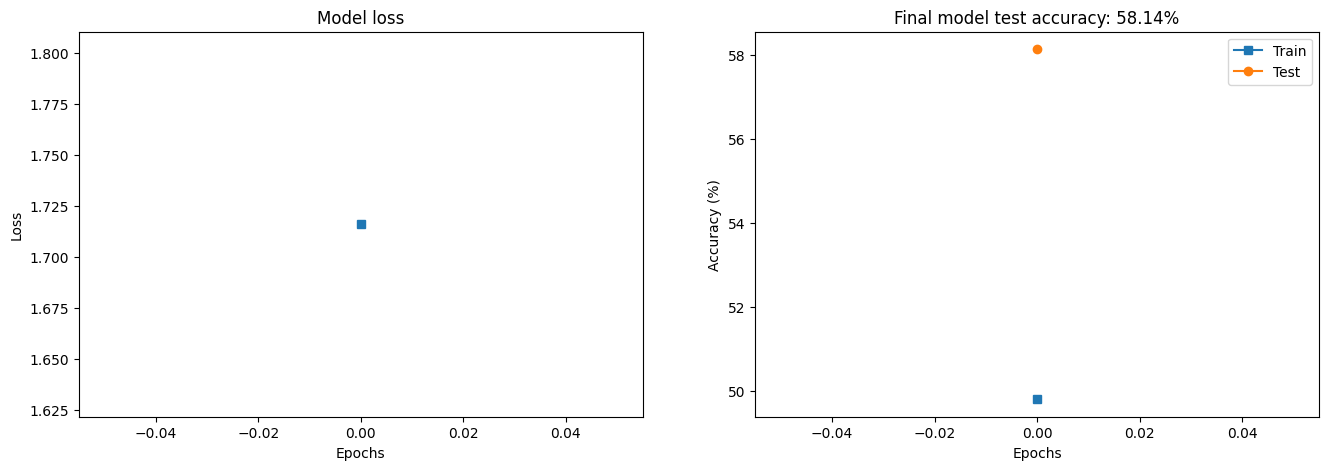

In [ ]:
#now let us train the model on EMNIST for 1 epoch and only changing the Linear output layer

for param in model.parameters():
    param.requires_grad = False
    
    
model.fc = nn.Linear(model.fc.in_features, 26)
model = model.to(device)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
lossfun=nn.CrossEntropyLoss()
trainAcc, testAcc, losses, net = function2trainTheModel(model , optimizer , EMNIST_train_loader , EMNIST_test_loader , numepochs=1)
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(losses,'s-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')

ax[1].plot(trainAcc,'s-',label='Train')
ax[1].plot(testAcc,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.show()




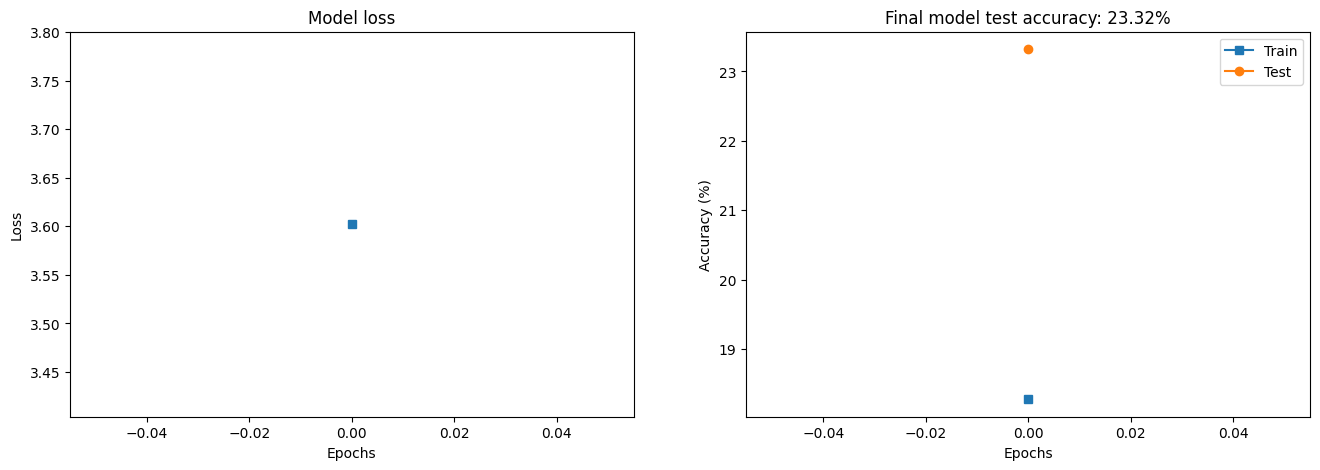

In [ ]:
#now let us train the model on CIFAR100 and only changing the final output layer

for param in model.parameters():
    param.requires_grad = False
    
    
model.fc = nn.Linear(model.fc.in_features, 100)
model = model.to(device)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
lossfun=nn.CrossEntropyLoss()
trainAcc, testAcc, losses, net = function2trainTheModel(model , optimizer , CIFAR100_trainloader , CIFAR100_testloader , numepochs=1)
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(losses,'s-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')

ax[1].plot(trainAcc,'s-',label='Train')
ax[1].plot(testAcc,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.show()




In [ ]:
#FINE TUNING THE MODEL NOW and apply on EMNIST
# Freeze everything
for param in model.parameters():
    param.requires_grad = False

# Replace FC
model.fc = nn.Linear(model.fc.in_features, 26)

# Unfreeze last block + FC
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True
    


model = model.to(device)
optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3}
])

lossfun=nn.CrossEntropyLoss()
trainAcc, testAcc, losses, net = function2trainTheModel(model , optimizer , EMNIST_train_loader , EMNIST_test_loader , numepochs=10)
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(losses,'s-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')

ax[1].plot(trainAcc,'s-',label='Train')
ax[1].plot(testAcc,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.show()





/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
#FINE TUNING THE MODEL NOW and apply on CIFAR100
# Freeze everything
for param in model.parameters():
    param.requires_grad = False

# Replace FC
model.fc = nn.Linear(model.fc.in_features, 100)

# Unfreeze last block + FC
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True
    


model = model.to(device)
optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3}
])

lossfun=nn.CrossEntropyLoss()
trainAcc, testAcc, losses, net = function2trainTheModel(model , optimizer , CIFAR100_trainloader,CIFAR100_testloader , numepochs=10)
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(losses,'s-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')

ax[1].plot(trainAcc,'s-',label='Train')
ax[1].plot(testAcc,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.show()





In [ ]:
'''Situation	                                 Best CNN	                               Why

1.General starting point	                     ResNet-50	                               Best balance of accuracy, speed, community support. Works everywhere.

2.Need max accuracy, have GPU	                 EfficientNet-B4/B5	                       Best accuracy-per-parameter. ImageNet SOTA for its compute class.

3.Mobile / edge deployment	                     MobileNetV3 or EfficientNet-B0	           Tiny model, fast inference, designed for on-device use.

4.Medical imaging (X-ray, CT, histology)	     DenseNet-121 or ResNet-50	               DenseNet-121 used in CheXNet. Dense connections help with subtle features.

5.Object detection backbone	                     ResNet-50/101 or ResNeXt	               FPN (Feature Pyramid Network) was designed for ResNet. Industry standard.

6.Semantic segmentation backbone	             ResNet + DeepLab / UNet	               ResNet encoder + decoder head is the most common segmentation setup.

7.Style transfer	                             VGG-19	                                   Gram matrix features from VGG are standard for perceptual/style loss.

8.Very small dataset (<500 imgs)	             EfficientNet-B0 or MobileNetV2	           Smaller models overfit less when fine-tuning on tiny datasets.

9.Fastest training / prototyping	             ResNet-18 or MobileNetV2	               Lightweight, fast to iterate. Good for experiments before scaling up.'''
